In [16]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from pathlib import Path

# style
sns.set_style("whitegrid")

# path
base_path = Path().resolve().parent

In [17]:
df = pd.read_csv(base_path / "ukraine-book-publishing-analysis/data/processed/ukraine_books.csv")

df.head() 


,year,total_titles,total_copies_mln,ukr_copies_mln,rus_copies_mln,edu_titles,fiction_titles,non_fiction_titles,avg_print_run,ukr_share_pct,other_copies_mln,non_fiction_share_pct
0,1991,5855,136.4,45.5,85.2,NaN,NaN,NaN,23296.0,33.36,5.7,NaN
1,1992,5451,125.8,41.2,79.5,NaN,NaN,NaN,23078.0,32.75,5.1,NaN
2,1993,5136,89.2,35.1,49.1,NaN,NaN,NaN,17368.0,39.35,5.0,NaN
3,1994,4710,54.1,31.5,19.5,NaN,NaN,NaN,11486.0,58.23,3.1,NaN
4,1995,6109,48.2,28.1,17.1,NaN,NaN,NaN,7890.0,58.30,3.0,NaN


In [18]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 35 entries, 0 to 34
Data columns (total 12 columns):
 #   Column                 Non-Null Count  Dtype  
---  ------                 --------------  -----  
 0   year                   35 non-null     int64  
 1   total_titles           35 non-null     int64  
 2   total_copies_mln       35 non-null     float64
 3   ukr_copies_mln         35 non-null     float64
 4   rus_copies_mln         35 non-null     float64
 5   edu_titles             17 non-null     float64
 6   fiction_titles         17 non-null     float64
 7   non_fiction_titles     17 non-null     float64
 8   avg_print_run          35 non-null     float64
 9   ukr_share_pct          35 non-null     float64
 10  other_copies_mln       35 non-null     float64
 11  non_fiction_share_pct  17 non-null     float64
dtypes: float64(10), int64(2)
memory usage: 3.4 KB


In [19]:
df.describe()

,year,total_titles,total_copies_mln,ukr_copies_mln,rus_copies_mln,edu_titles,fiction_titles,non_fiction_titles,avg_print_run,ukr_share_pct,other_copies_mln,non_fiction_share_pct
count,35.000000,35.000000,35.000000,35.000000,35.000000,17.000000,17.000000,17.000000,35.000000,35.000000,35.000000,17.000000
mean,2008.000000,15299.571429,51.142857,29.542857,18.865429,8867.647059,3611.764706,2735.294118,4950.628571,62.405143,2.734571,13.680588
std,10.246951,7174.376859,24.990908,9.139098,18.468045,1994.597483,638.242071,482.106286,5595.683006,16.497729,6.310200,1.875965
min,1991.000000,4710.000000,11.600000,7.500000,0.250000,3800.000000,1800.000000,1300.000000,994.000000,32.750000,-12.200000,11.120000
25%,1999.500000,7324.000000,40.450000,27.500000,10.500000,8500.000000,3400.000000,2500.000000,2140.000000,56.280000,1.400000,12.160000
50%,2008.000000,15187.000000,48.500000,30.100000,16.200000,9200.000000,3800.000000,2800.000000,2640.000000,58.760000,2.700000,13.210000
75%,2016.500000,22034.500000,55.300000,33.100000,20.000000,9800.000000,4100.000000,3100.000000,4292.500000,69.440000,4.350000,14.700000
max,2025.000000,26323.000000,136.400000,48.200000,85.200000,12100.000000,4500.000000,3500.000000,23296.000000,101.900000,21.300000,17.250000


In [20]:
df.isna().sum()

year                      0
total_titles              0
total_copies_mln          0
ukr_copies_mln            0
rus_copies_mln            0
edu_titles               18
fiction_titles           18
non_fiction_titles       18
avg_print_run             0
ukr_share_pct             0
other_copies_mln          0
non_fiction_share_pct    18
dtype: int64

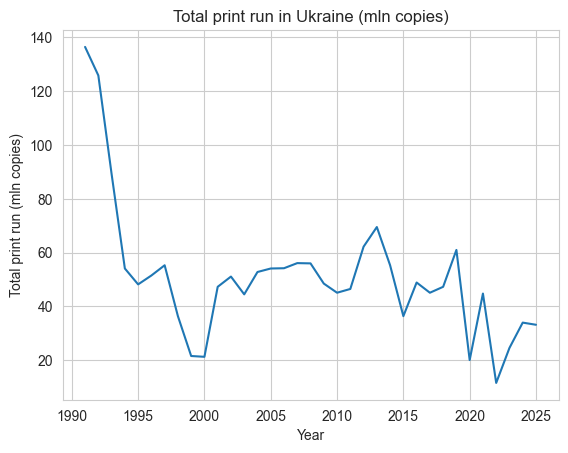

In [21]:
plt.figure()
plt.plot(df["year"], df["total_copies_mln"])
plt.title("Total print run in Ukraine (mln copies)")
plt.xlabel("Year")
plt.ylabel("Total print run (mln copies)")
plt.show()

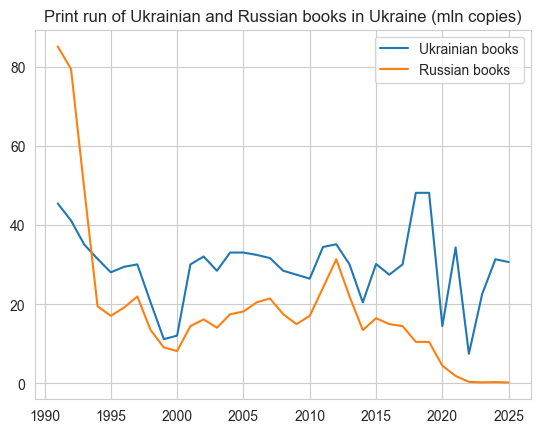

In [22]:
plt.figure()
plt.plot(df["year"], df["ukr_copies_mln"], label="Ukrainian books")
plt.plot(df["year"], df["rus_copies_mln"], label="Russian books")
plt.legend()
plt.title("Print run of Ukrainian and Russian books in Ukraine (mln copies)")
plt.show()

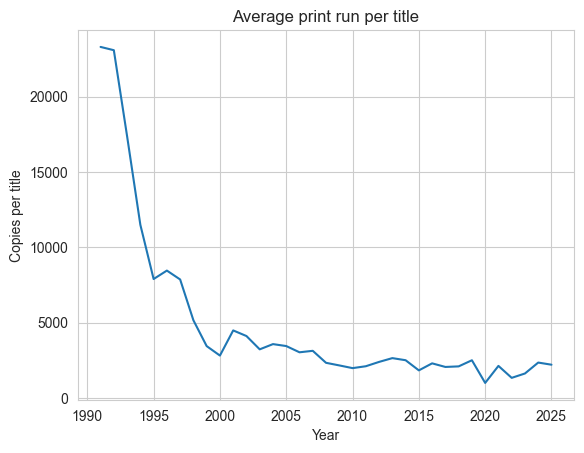

In [23]:
plt.figure()
plt.plot(df["year"], df["avg_print_run"])

plt.title("Average print run per title")
plt.xlabel("Year")
plt.ylabel("Copies per title")

plt.show()

In [24]:
# Delete the edu books
df_no_edu = df[df["edu_titles"].isna() == False]

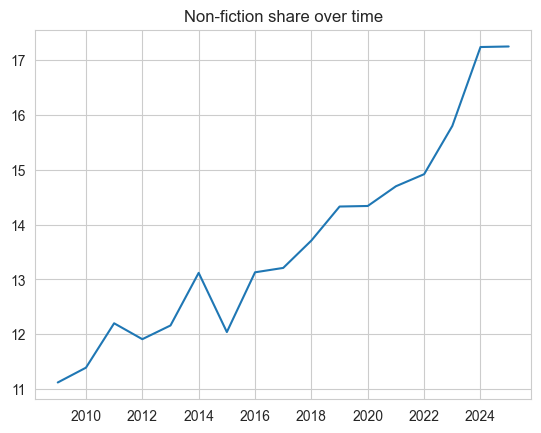

In [26]:
plt.figure()
plt.plot(df_no_edu["year"], df_no_edu["non_fiction_share_pct"])

plt.title("Non-fiction share over time")
plt.show()

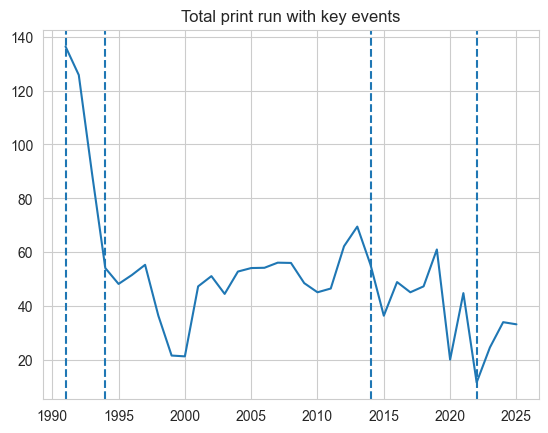

In [27]:
plt.figure()
plt.plot(df['year'], df['total_copies_mln'])

for year in [1991, 1994, 2014, 2022]:
    plt.axvline(x=year, linestyle='--')

plt.title('Total print run with key events')
plt.show()

In [28]:
df.groupby(pd.cut(df['year'], bins=[1990,1994,1999,2004,2010,2020,2025]))['total_copies_mln'].mean()

/var/folders/p0/h3y7y30n1b5blkgn9hvfmr5h0000gn/T/ipykernel_2538/1292436198.py:1: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  df.groupby(pd.cut(df['year'], bins=[1990,1994,1999,2004,2010,2020,2025]))['total_copies_mln'].mean()


year
(1990, 1994]    101.375000
(1994, 1999]     42.600000
(1999, 2004]     43.400000
(2004, 2010]     52.333333
(2010, 2020]     49.230000
(2020, 2025]     29.640000
Name: total_copies_mln, dtype: float64